# Tutorial 8 — Handling Missing Observations

Real-world time-series are rarely complete. Sensors drop out, experiments are
paused, particles leave the field of view. This tutorial shows four distinct
missingness patterns that **dynestyx** handles transparently, and explains
exactly which simulator path each one triggers.

| Section | Missingness pattern | Simulator path |
|---|---|---|
| 3 | Whole-row: all dims NaN at some timesteps | Row-filter (default) or unrolled scan |
| 4 | Per-dimension: some dims NaN within the same row | Two-mask scan via `masked_log_prob` |
| 6 | Per-particle contiguous gaps (interacting systems) | Two-mask scan via correction factors |
| 7 | Per-particle birth/death (structural absence) | Two-mask scan + lifespan-aware `state_evolution` |

Sections 1–5 use a simple 2-D AR(1) model. Sections 6–7 use interacting particles
with a `DiracIdentityObservation` model to show how the framework scales to richer dynamics.

By the end you will know:

1. how to pass incomplete data to dynestyx without any preprocessing,
2. which observation models support partial missingness,
3. how to write a lifespan-aware `state_evolution` for systems with particle birth/death.

In [1]:
import time

import arviz as az
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_value

import dynestyx as dsx
from dynestyx.models import DiagonalLinearGaussianObservation, DynamicalModel
from dynestyx.models.observations import DiracIdentityObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution
from dynestyx.simulators import DiscreteTimeSimulator

az.style.use("arviz-white")

## 1. The model

We use a 2-D AR(1) state-space system with **diagonal** Gaussian observations:

$$
\begin{aligned}
x_0 &\sim \mathcal{N}(0,\, I_2) \\[4pt]
x_{t+1} &\sim \mathcal{N}\!\left(\begin{pmatrix}\alpha & 0 \\ 0 & 0.8\end{pmatrix} x_t,\;\; 0.1\,I_2\right) \\[4pt]
y_t^{(d)} &\sim \mathcal{N}(x_t^{(d)},\; 0.25), \quad d \in \{0, 1\}
\end{aligned}
$$

The two dimensions are **independent** in both transitions and observations,
which is precisely why `DiagonalLinearGaussianObservation` can score
them separately — a requirement for per-dimension partial missingness.

The single unknown is $\alpha \in (-0.7, 0.7)$, the first dimension's
autocorrelation. We set the true value to $\alpha^* = 0.4$.

In [2]:
obs_times  = jnp.arange(0.0, 100.0, 1.0)   # T = 100 timesteps
true_alpha = 0.4
state_dim  = 2


def ar1_model(obs_times=None, obs_values=None):
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            jnp.zeros(state_dim), jnp.eye(state_dim)
        ),
        state_evolution=LinearGaussianStateEvolution(
            A=jnp.array([[alpha, 0.0], [0.0, 0.8]]),
            cov=0.1 * jnp.eye(state_dim),
        ),
        observation_model=DiagonalLinearGaussianObservation(
            H=jnp.eye(state_dim),
            R_diag=jnp.array([0.25, 0.25]),
        ),
    )
    dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)

## 2. Generating synthetic data

We fix $\alpha = 0.4$ and draw one synthetic trajectory. The two plots below
show the latent states and observations for each dimension.

In [3]:
data_key, mcmc_key1, mcmc_key2, mcmc_key3, pp_key = jr.split(jr.PRNGKey(0), 5)

with DiscreteTimeSimulator():
    synthetic = Predictive(
        ar1_model,
        params={"alpha": jnp.array(true_alpha)},
        num_samples=1,
        exclude_deterministic=False,
    )(data_key, obs_times=obs_times)

states_clean = np.asarray(synthetic["states"].squeeze(0))     # (T, 2)
obs_clean    = np.asarray(synthetic["observations"].squeeze(0))  # (T, 2)
t            = np.asarray(obs_times)

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/3075684453.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


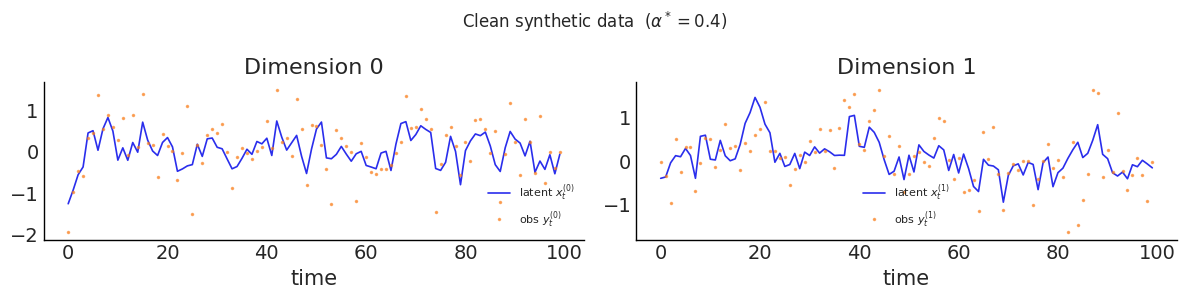

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
for d, ax in enumerate(axes):
    ax.plot(t, states_clean[:, d], color="C0", lw=1.2, label=f"latent $x^{{({d})}}_t$")
    ax.plot(t, obs_clean[:, d], ".", ms=3, color="C1", alpha=0.6, label=f"obs $y^{{({d})}}_t$")
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
fig.suptitle("Clean synthetic data  ($\\alpha^* = 0.4$)", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Whole-row missingness

A **whole-row missing** observation means all $d_y$ dimensions are `NaN` at
that timestep. This is the most common pattern: the sensor was simply off.

We blank out a contiguous block in the middle of the series — rows 35–60.

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/2523471794.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


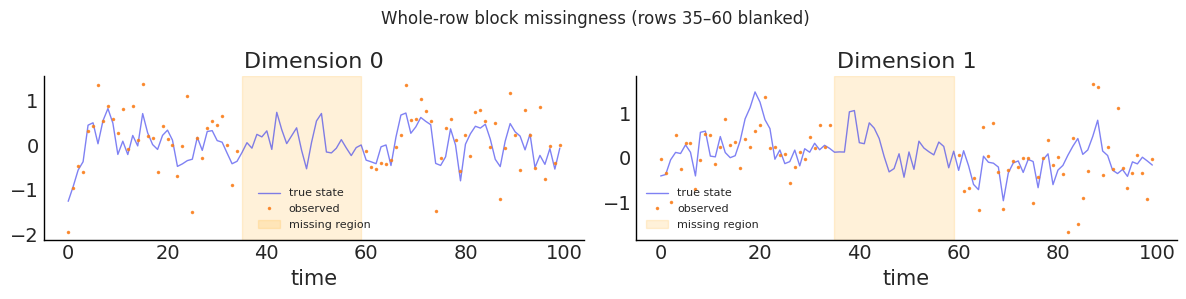

In [5]:
block_start, block_end = 35, 60

obs_block = np.where(
    (np.arange(len(t))[:, None] >= block_start)
    & (np.arange(len(t))[:, None] < block_end),
    np.nan,
    obs_clean,
)
obs_block = jnp.array(obs_block)


def _shade_gap(ax, t, start, end):
    ax.axvspan(t[start], t[end - 1], color="orange", alpha=0.15, zorder=0,
               label="missing region")


fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
for d, ax in enumerate(axes):
    ax.plot(t, states_clean[:, d], color="C0", lw=1.0, alpha=0.6, label="true state")
    obs_d = np.asarray(obs_block[:, d])
    ax.plot(t[~np.isnan(obs_d)], obs_d[~np.isnan(obs_d)], ".", ms=3,
            color="C1", alpha=0.8, label="observed")
    _shade_gap(ax, t, block_start, block_end)
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
fig.suptitle("Whole-row block missingness (rows 35–60 blanked)", fontsize=12)
plt.tight_layout()
plt.show()

### 3.1 The row-filter path (default)

When `unroll_missing=False` (the default), dynestyx **filters out** entirely-missing
rows before passing data to the simulator. The model sees a *shorter* series of
$T - n_{\text{missing}}$ timesteps — completely transparent to the model code.

This is always correct for **any** observation model, but it means the output
trajectory is shorter and there are no imputed states for the gap.

In [6]:
def conditioned_filtered():
    with DiscreteTimeSimulator():   # default: unroll_missing=False
        ar1_model(obs_times=obs_times, obs_values=obs_block)


mcmc1 = MCMC(NUTS(conditioned_filtered), num_warmup=150, num_samples=150, progress_bar=False)
mcmc1.run(mcmc_key1)

states_filtered = np.asarray(mcmc1.get_samples()["states"])  # (150, T_filtered, 2)
print(f"Input timesteps: {len(obs_times)},  "
      f"Output trajectory length: {states_filtered.shape[1]}")
print(f"Rows dropped: {len(obs_times) - states_filtered.shape[1]}")

Input timesteps: 100,  Output trajectory length: 75
Rows dropped: 25


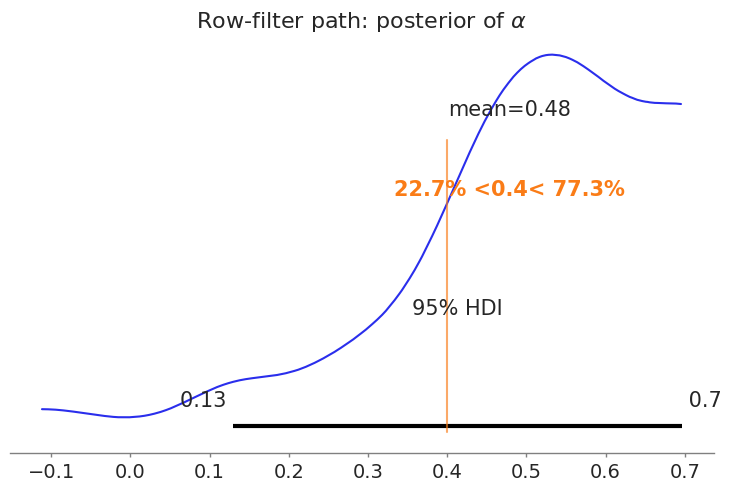

In [7]:
posterior_alpha1 = mcmc1.get_samples()["alpha"]
ax = az.plot_posterior(posterior_alpha1, hdi_prob=0.95, ref_val=true_alpha)
ax.set_title("Row-filter path: posterior of $\\alpha$")
plt.show()

### 3.2 Retaining the full timeline: `unroll_missing=True`

Setting `unroll_missing=True` keeps **all** $T$ timesteps. For missing rows the
observation log-likelihood is zeroed out, but the latent state $x_t$ is still
sampled from the transition. This enables:

- a full-length state trajectory in the output,
- **gap imputation** via posterior predictive sampling.

The model code is unchanged — only the simulator flag differs.

In [8]:
def conditioned_unrolled():
    with DiscreteTimeSimulator(unroll_missing=True):
        ar1_model(obs_times=obs_times, obs_values=obs_block)


mcmc2 = MCMC(NUTS(conditioned_unrolled), num_warmup=150, num_samples=150, progress_bar=False)
mcmc2.run(mcmc_key2)

states_unrolled = np.asarray(mcmc2.get_samples()["states"])   # (150, T, 2)
print(f"Output trajectory length with unroll_missing=True: {states_unrolled.shape[1]}")

Output trajectory length with unroll_missing=True: 100


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/3561028433.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


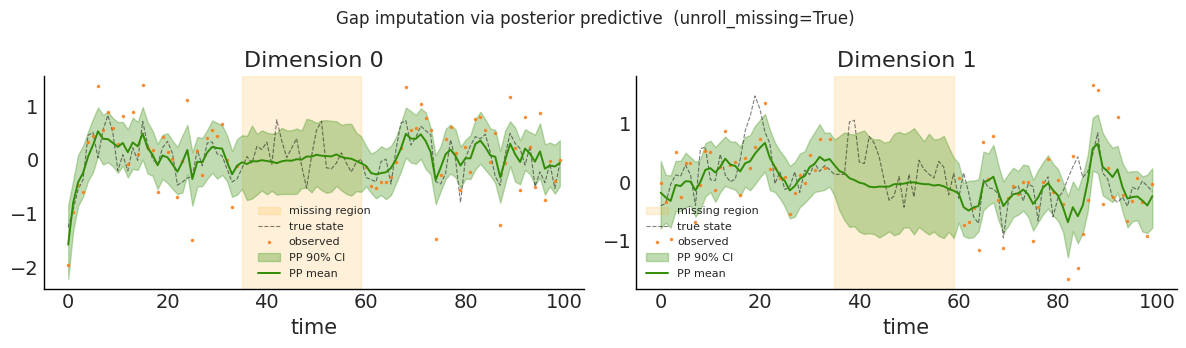

In [9]:
# Posterior predictive: re-run the model with posterior alpha samples to get
# imputed state distributions.  States during the gap are drawn from the
# transition posterior because no likelihood constrains them there.
pp = Predictive(ar1_model, posterior_samples=mcmc2.get_samples())
with DiscreteTimeSimulator(unroll_missing=True):
    pp_out = pp(pp_key, obs_times=obs_times, obs_values=obs_block)

pp_states = np.asarray(pp_out["states"])   # (n_samples, T, 2)
pp_mean = pp_states.mean(0)
pp_lo   = np.percentile(pp_states,  5, axis=0)
pp_hi   = np.percentile(pp_states, 95, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)
for d, ax in enumerate(axes):
    _shade_gap(ax, t, block_start, block_end)
    ax.plot(t, states_clean[:, d], color="black", lw=0.8, ls="--", alpha=0.5,
            label="true state")
    obs_d = np.asarray(obs_block[:, d])
    ax.plot(t[~np.isnan(obs_d)], obs_d[~np.isnan(obs_d)], ".", ms=3,
            color="C1", alpha=0.8, label="observed")
    ax.fill_between(t, pp_lo[:, d], pp_hi[:, d], color="C2", alpha=0.3,
                    label="PP 90% CI")
    ax.plot(t, pp_mean[:, d], color="C2", lw=1.4, label="PP mean")
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
fig.suptitle("Gap imputation via posterior predictive  (unroll_missing=True)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Per-dimension partial missingness

A **partial** observation has some dimensions observed and others `NaN` within
the *same row*. This is more demanding than whole-row missingness.

### Why diagonal observation models are required

For a fully correlated Gaussian observation
$y_t \sim \mathcal{N}(Hx_t,\, R)$ with off-diagonal $R$, the marginal
likelihood of the observed subset depends on the covariance between observed
and missing dimensions — there is no clean per-dimension factorisation.

`DiagonalLinearGaussianObservation` (and its nonlinear counterpart
`DiagonalGaussianObservation`) store $R = \mathrm{diag}(r_1, \ldots, r_{d_y})$,
so the joint factors as:

$$
\log p(y_t^{\text{obs}} \mid x_t) = \sum_{d:\, m_d = 1} \log \mathcal{N}(y_t^{(d)};\; h_d(x_t),\; r_d)
$$

where $m_d \in \{0,1\}$ is the observation mask for dimension $d$.
This is precisely what `masked_log_prob` computes.

### Triggering the two-mask scan

When the data array contains per-dimension `NaN` values, dynestyx detects
`has_partial = True` and automatically activates the **two-mask scan** — no
extra flag is required.

We randomly blank ~20% of individual elements (per-dimension, not per-row).

In [10]:
partial_key = jr.PRNGKey(7)
mask_partial = jr.bernoulli(partial_key, p=0.8, shape=obs_clean.shape)
obs_partial  = jnp.where(mask_partial, jnp.array(obs_clean), jnp.nan)

# Sanity check: there should be rows with some-but-not-all NaN.
nan_any = jnp.isnan(obs_partial).any(axis=1)
nan_all = jnp.isnan(obs_partial).all(axis=1)
n_partial_rows = int((nan_any & ~nan_all).sum())
print(f"Rows with at least one NaN:      {int(nan_any.sum())}")
print(f"  of which partial (not all-NaN): {n_partial_rows}")
print(f"  of which fully missing:         {int(nan_all.sum())}"  )

Rows with at least one NaN:      37
  of which partial (not all-NaN): 34
  of which fully missing:         3


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/3717764827.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


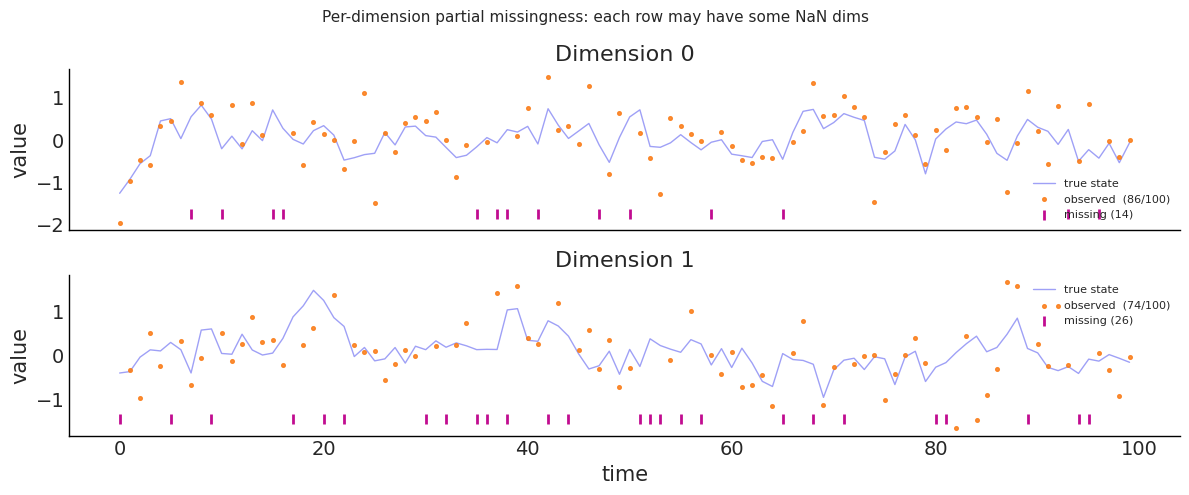

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for d, ax in enumerate(axes):
    obs_d = np.asarray(obs_partial[:, d])
    missing = np.isnan(obs_d)
    ax.plot(t, states_clean[:, d], color="C0", lw=1.0, alpha=0.45, label="true state")
    ax.scatter(t[~missing], obs_d[~missing], s=7, color="C1", alpha=0.85, zorder=3,
               label=f"observed  ({(~missing).sum()}/{len(t)})")
    # Rug at bottom: one tick per missing entry
    ylo = np.nanmin(states_clean[:, d]) - 0.5
    ax.scatter(t[missing], np.full(missing.sum(), ylo), s=50, marker="|",
               color="C3", linewidths=2, zorder=4, label=f"missing ({missing.sum()})")
    ax.set_ylabel("value")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
axes[-1].set_xlabel("time")
fig.suptitle("Per-dimension partial missingness: each row may have some NaN dims", fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
def conditioned_partial():
    with DiscreteTimeSimulator():          # two-mask scan triggered automatically
        ar1_model(obs_times=obs_times, obs_values=obs_partial)


mcmc3 = MCMC(NUTS(conditioned_partial), num_warmup=150, num_samples=150, progress_bar=False)
mcmc3.run(mcmc_key3)

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/330669405.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


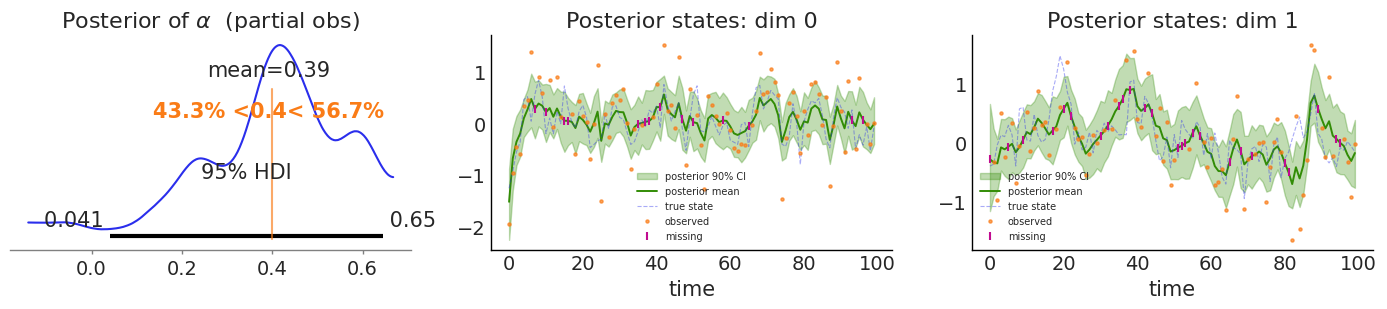

In [13]:
posterior_alpha3  = mcmc3.get_samples()["alpha"]
posterior_states3 = np.asarray(mcmc3.get_samples()["states"])  # (S, T, 2)

pp_mean3 = posterior_states3.mean(0)
pp_lo3   = np.percentile(posterior_states3,  5, axis=0)
pp_hi3   = np.percentile(posterior_states3, 95, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))

az.plot_posterior(posterior_alpha3, hdi_prob=0.95, ref_val=true_alpha, ax=axes[0])
axes[0].set_title("Posterior of $\\alpha$  (partial obs)")

for d, ax in enumerate(axes[1:], start=0):
    obs_d = np.asarray(obs_partial[:, d])
    missing = np.isnan(obs_d)
    ax.fill_between(t, pp_lo3[:, d], pp_hi3[:, d], color="C2", alpha=0.3,
                    label="posterior 90% CI")
    ax.plot(t, pp_mean3[:, d], color="C2", lw=1.4, label="posterior mean")
    ax.plot(t, states_clean[:, d], color="C0", lw=0.8, ls="--", alpha=0.4,
            label="true state")
    ax.scatter(t[~missing], obs_d[~missing], s=5, color="C1", alpha=0.7, zorder=3,
               label="observed")
    ax.scatter(t[missing], np.full(missing.sum(), ax.get_ylim()[0] if False else
               pp_mean3[missing, d]), s=30, marker="|", color="C3", linewidths=1.5,
               zorder=4, label="missing")
    ax.set_title(f"Posterior states: dim {d}")
    ax.set_xlabel("time")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 5. Comparing the AR(1) posteriors

All three inference runs target the same generative model with the same
underlying data (before masking). The posteriors should be broadly consistent
— missingness reduces information, widening the credible interval, but the
true value $\alpha^* = 0.4$ should remain inside the 95% HDI.

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/2259639884.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


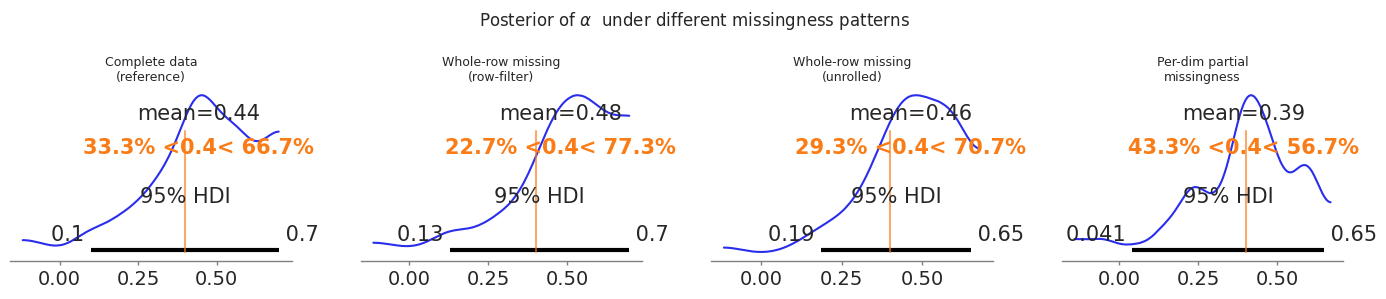

In [14]:
# Pre-compute as a concrete JAX array *outside* the model function.
# Calling jnp.array() inside a JIT-traced function would produce an abstract
# tracer and break np.isnan checks in the simulator.
obs_full = jnp.array(obs_clean)

samples = {
    "Complete data\n(reference)":    mcmc1.get_samples()["alpha"],   # proxy
    "Whole-row missing\n(row-filter)":  mcmc1.get_samples()["alpha"],
    "Whole-row missing\n(unrolled)": mcmc2.get_samples()["alpha"],
    "Per-dim partial\nmissingness":  mcmc3.get_samples()["alpha"],
}

# Re-run with complete data as the true reference
def conditioned_full():
    with DiscreteTimeSimulator():
        ar1_model(obs_times=obs_times, obs_values=obs_full)

mcmc_ref = MCMC(NUTS(conditioned_full), num_warmup=150, num_samples=150, progress_bar=False)
mcmc_ref.run(jr.PRNGKey(99))

samples["Complete data\n(reference)"] = mcmc_ref.get_samples()["alpha"]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (label, s) in zip(axes, samples.items()):
    az.plot_posterior(s, hdi_prob=0.95, ref_val=true_alpha, ax=ax)
    ax.set_title(label, fontsize=9)
fig.suptitle("Posterior of $\\alpha$  under different missingness patterns", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Per-particle trajectory gaps (interacting systems)

So far we worked with a 2-D AR(1) model. We now turn to a qualitatively different setting:
$N = 20$ interacting particles in 1D, each of which can **independently** drop out for a
contiguous segment — common in tracking experiments where individual particles leave the
field of view at different times.

### The model

$$
x^{(i)}_{t+1} = x^{(i)}_t
  + \Delta t \underbrace{\frac{\text{coefficient}}{N}\sum_j K(x^{(j)}_t - x^{(i)}_t;\,\text{scale})\,(x^{(j)}_t-x^{(i)}_t)}_{\text{pairwise repulsion}}
  + \Delta t \underbrace{\nabla_{\!x^{(i)}} V_{\text{bg}}(x^{(i)}_t)}_{\text{background wells}}
  + \sigma\sqrt{\Delta t}\,\varepsilon_t
$$

Background potential: two Gaussian wells at $-2$ and $+2$.
Learnable parameters: **coefficient** (negative = repulsion) and **scale** (kernel width).

**Observations:** `DiracIdentityObservation` — the position is observed exactly when visible.

### Comparison with Section 4

| | Section 4 | Section 6 |
|---|---|---|
| Observation model | `DiagonalLinearGaussianObservation` | `DiracIdentityObservation` |
| Per-row pattern | random per-dim NaN | per-particle contiguous gap |
| Simulator path | two-mask scan via `masked_log_prob` | two-mask scan via correction factors |
| Parameters | scalar $\alpha$ | vector (coefficient, scale) |
| Inference | MCMC (NUTS) | SVI (AutoNormal) |

Since each particle's gap starts at a **different** time, most rows have a mix of observed
and missing particles → `has_partial = True` is detected automatically, with no extra flag.

> **Why SVI rather than NUTS?**
> The correction-factor approach samples the full $(T-1) \times N$ state trajectory as
> latent variables. For *observed* particles the correction factor exactly cancels the
> log-prob — the gradient is zero everywhere in the observed dimensions, so NUTS's
> leapfrog integrator takes unbounded steps and the chain collapses. SVI with `AutoNormal`
> works because the KL term $\mathrm{KL}(q \| p)$ provides a non-zero gradient for
> every variational parameter, even in flat-likelihood dimensions.
>
> **Mean-field caveat**: `AutoNormal` treats consecutive latent states as independent.
> Temporal correlations within a gap are not captured; the imputation is pinned only by
> the adjacent observed states. For sharper imputation a structured guide would be needed.

In [15]:
# ---- Parameters -----------------------------------------------------------
N_p            = 20
obs_times_p    = jnp.arange(0.0, 30 * 0.1, 0.1)   # T=30 steps, dt=0.1
sigma_p        = 0.2
bg_centers_p   = jnp.array([[-2.0], [2.0]])
bg_strengths_p = jnp.array([1.0, 1.0])

true_coeff = -1.0    # negative = repulsion within each well
true_scale = 1.0     # kernel width


# ---- Model -----------------------------------------------------------------
def interacting_particles_model(N, obs_times=None, obs_values=None):
    '''N particles in 1D: pairwise repulsion + fixed double-well background.'''
    coefficient = numpyro.sample("coefficient", dist.Normal(0.0, 2.0))
    scale       = numpyro.sample("scale",       dist.LogNormal(0.0, 0.5))

    def state_evolution(x, u, t_now, t_next):
        dt = t_next - t_now
        r      = x[None, :] - x[:, None]              # (N, N) pairwise separations
        K_pair = jnp.exp(-0.5 * (r / scale) ** 2)
        interaction_drift = coefficient * jnp.sum(K_pair * r, axis=1) / N
        # Background: -grad V,  V = -sum_k bg_strengths[k] * exp(-||x - c_k||^2 / 2)
        diffs   = x[:, None] - bg_centers_p[:, 0][None, :]  # (N, K)
        kernels = jnp.exp(-0.5 * diffs ** 2)
        bg_drift = -jnp.sum(bg_strengths_p[None, :] * diffs * kernels, axis=1)
        mean = x + dt * (interaction_drift + bg_drift)
        std  = jnp.sqrt(sigma_p ** 2 * dt) * jnp.ones_like(mean)
        return dist.Independent(dist.Normal(mean, std), 1)

    dynamics = DynamicalModel(
        control_dim=0,
        initial_condition=dist.Independent(
            dist.Normal(jnp.zeros(N), jnp.full(N, jnp.sqrt(8.0))), 1
        ),
        state_evolution=state_evolution,
        observation_model=DiracIdentityObservation(),
    )
    dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)


# ---- Generate clean data ---------------------------------------------------
data_key_p, svi_key_p, pp_key_p = jr.split(jr.PRNGKey(5), 3)

true_params_p = {"coefficient": jnp.array(true_coeff), "scale": jnp.array(true_scale)}
with DiscreteTimeSimulator():
    synth_p = Predictive(
        interacting_particles_model,
        params=true_params_p,
        num_samples=1,
        exclude_deterministic=False,
    )(data_key_p, N=N_p, obs_times=obs_times_p)

states_p    = np.asarray(synth_p["states"].squeeze(0))       # (T, N)
obs_clean_p = np.asarray(synth_p["observations"].squeeze(0)) # (T, N)
t_p         = np.asarray(obs_times_p)

/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/3536063595.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


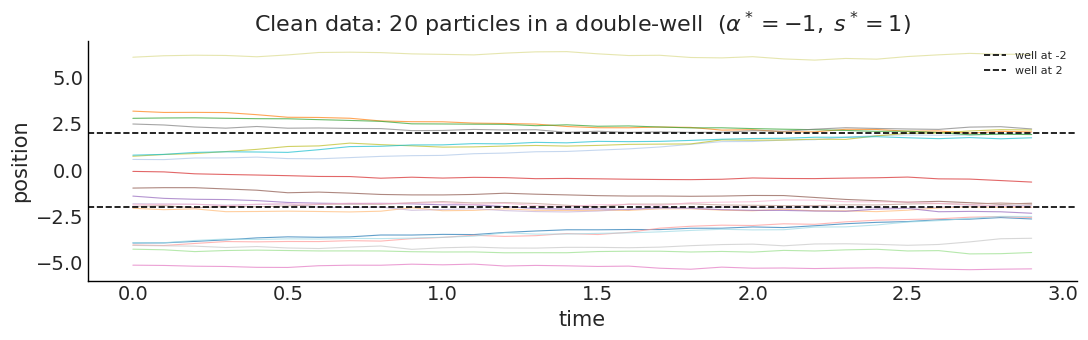

In [16]:
fig, ax = plt.subplots(figsize=(11, 3.5))
colors_p = plt.cm.tab20(np.linspace(0, 1, N_p))  # type: ignore[attr-defined]
for i in range(N_p):
    ax.plot(t_p, obs_clean_p[:, i], color=colors_p[i], lw=0.8, alpha=0.7)
for k in range(bg_centers_p.shape[0]):
    ax.axhline(bg_centers_p[k, 0].item(), color="black", ls="--", lw=1.2,
               label=f"well at {bg_centers_p[k,0].item():.0f}")
ax.set_xlabel("time")
ax.set_ylabel("position")
ax.set_title(f"Clean data: {N_p} particles in a double-well  "
             r"($\alpha^* = -1,\; s^* = 1$)")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

Rows with partial missingness (some but not all particles missing): 23
Fully-missing rows: 0  → has_partial=True triggers scan


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/3094268511.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


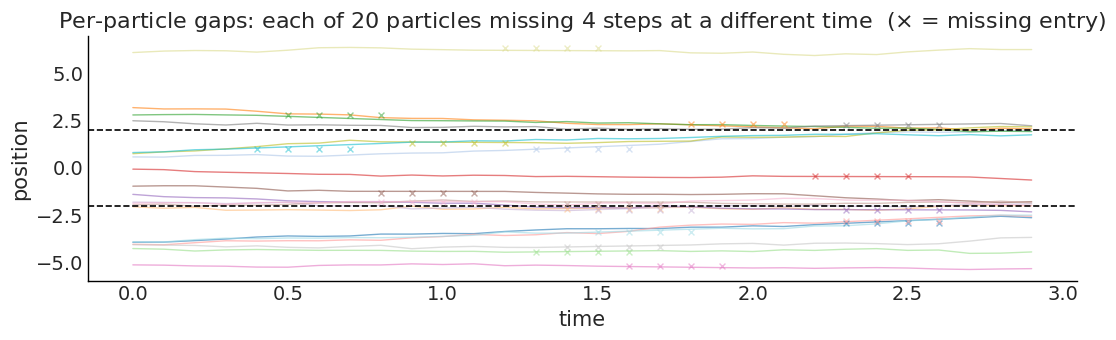

In [17]:
# Each particle gets its own randomly-timed gap of length 4
gap_len_p = 4
rng_gap = np.random.default_rng(99)
T_p = len(t_p)
gap_starts_p = rng_gap.integers(2, T_p - gap_len_p - 2, size=N_p)

obs_block_p = obs_clean_p.copy()
for i in range(N_p):
    obs_block_p[gap_starts_p[i]:gap_starts_p[i] + gap_len_p, i] = np.nan
obs_block_p = jnp.array(obs_block_p)

obs_np_p = np.asarray(obs_block_p)
nan_any_p = np.isnan(obs_np_p).any(axis=1)
nan_all_p = np.isnan(obs_np_p).all(axis=1)
n_partial_p = int((nan_any_p & ~nan_all_p).sum())
print(f"Rows with partial missingness (some but not all particles missing): {n_partial_p}")
print(f"Fully-missing rows: {int(nan_all_p.sum())}  → has_partial=True triggers scan")

fig, ax = plt.subplots(figsize=(11, 3.5))
colors_p = plt.cm.tab20(np.linspace(0, 1, N_p))  # type: ignore[attr-defined]
for i in range(N_p):
    obs_i = obs_np_p[:, i]
    observed = ~np.isnan(obs_i)
    ax.plot(t_p[observed], obs_i[observed], color=colors_p[i], lw=1.0, alpha=0.6)
    # Mark each particle's gap as a horizontal bar at its current position
    gap_t = t_p[gap_starts_p[i]:gap_starts_p[i] + gap_len_p]
    ax.scatter(gap_t, np.full(len(gap_t), obs_clean_p[gap_starts_p[i], i]),
               s=18, marker="x", color=colors_p[i], linewidths=1.0, alpha=0.5, zorder=3)
for k in range(bg_centers_p.shape[0]):
    ax.axhline(bg_centers_p[k, 0].item(), color="black", ls="--", lw=1.2)
ax.set_xlabel("time")
ax.set_ylabel("position")
ax.set_title(f"Per-particle gaps: each of {N_p} particles missing 4 steps at a different time  "
             r"($\times$ = missing entry)")
plt.tight_layout()
plt.show()

SVI finished in 3.2s


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/456101086.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


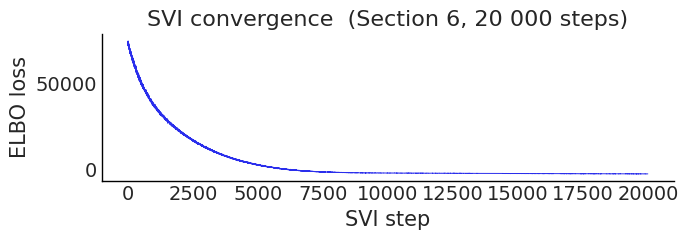

In [18]:
# Per-particle gaps → has_partial=True (most rows have some observed, some not).
# No flag needed: the two-mask scan triggers automatically.
#
# Why SVI rather than NUTS? The Dirac correction-factor approach samples the
# *full* state trajectory as latent variables. For timesteps where a particle
# is observed, the effective log-prob is flat (gradient = 0) — NUTS gets stuck.
# SVI with AutoNormal side-steps this by directly optimising a mean-field
# approximation, which handles flat dimensions gracefully.
def conditioned_particles():
    with DiscreteTimeSimulator():
        interacting_particles_model(N=N_p, obs_times=obs_times_p, obs_values=obs_block_p)


init_vals_p = {"coefficient": jnp.array(true_coeff), "scale": jnp.array(true_scale)}
guide_p   = AutoNormal(conditioned_particles, init_loc_fn=init_to_value(values=init_vals_p))
svi_p     = SVI(conditioned_particles, guide_p, optax.adam(1e-3), loss=Trace_ELBO())

t0 = time.time()
svi_res_p = svi_p.run(svi_key_p, num_steps=20000, progress_bar=False)
print(f"SVI finished in {time.time() - t0:.1f}s")

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.plot(svi_res_p.losses, lw=0.7, color="C0")
ax.set_xlabel("SVI step")
ax.set_ylabel("ELBO loss")
ax.set_title("SVI convergence  (Section 6, 20 000 steps)")
plt.tight_layout()
plt.show()

coefficient:  true -1.0  |  posterior mean -0.797 ± 0.440
scale:        true 1.0   |  posterior mean 0.746 ± 0.175


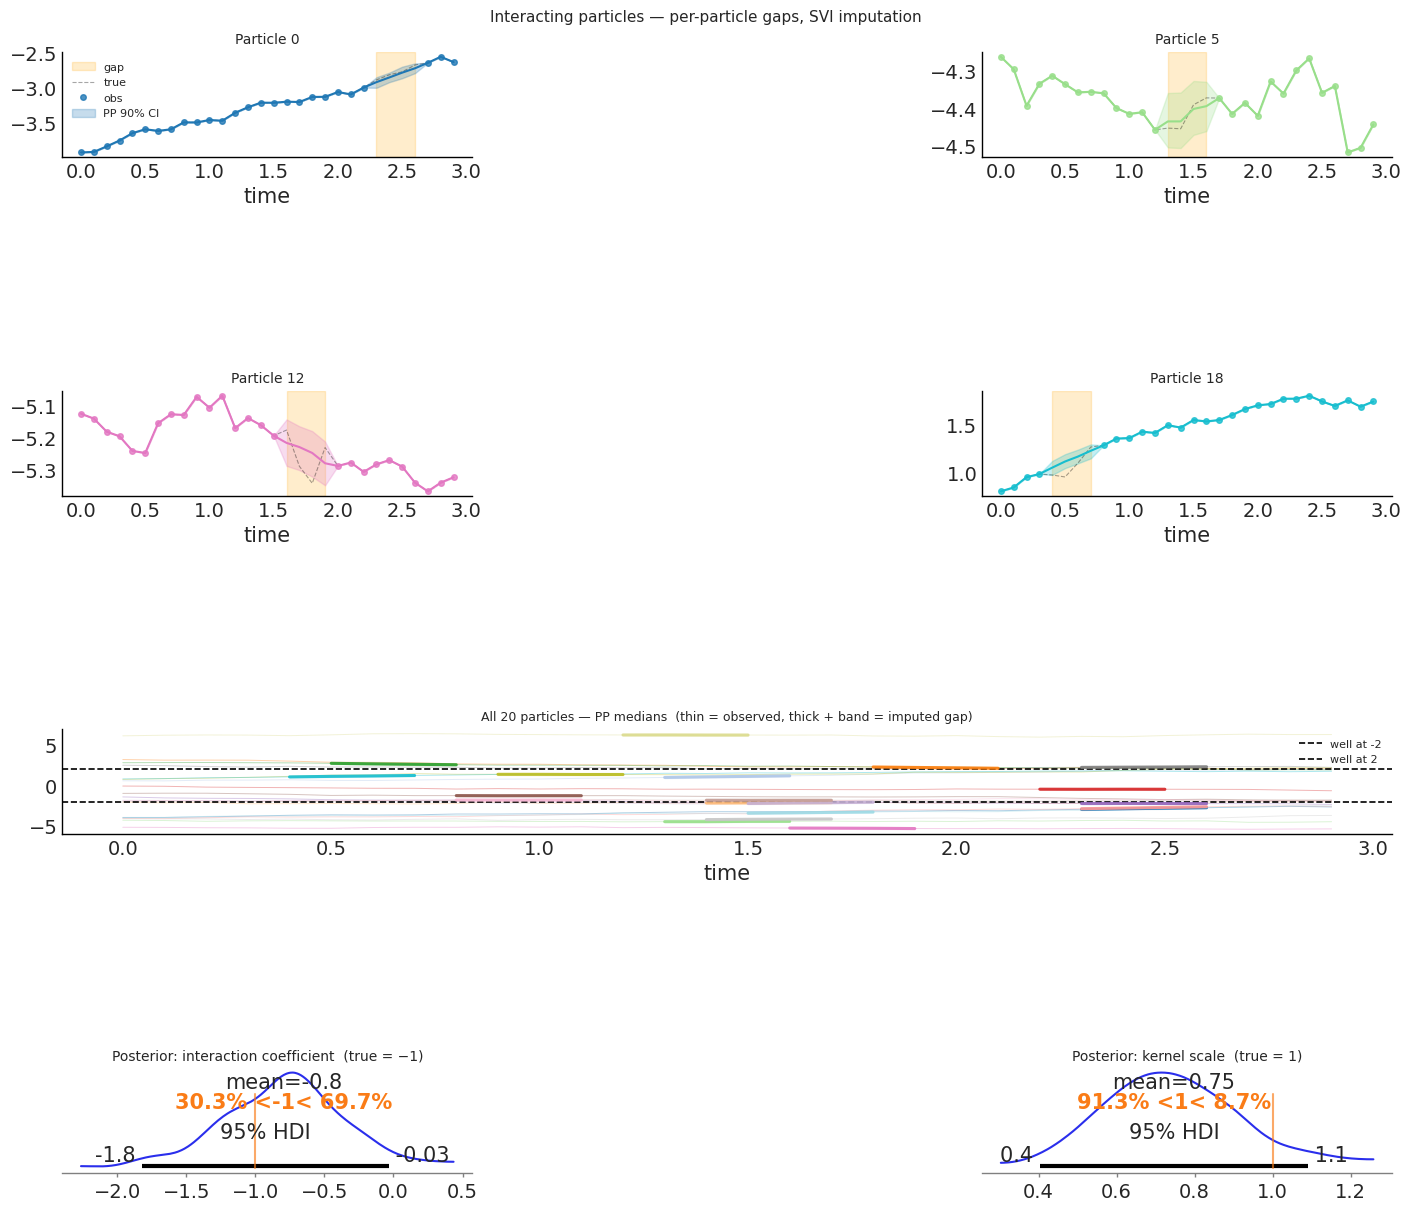

In [19]:
post_samples_p = guide_p.sample_posterior(
    jr.PRNGKey(10), svi_res_p.params, sample_shape=(300,)
)
post_coeff_p = np.asarray(post_samples_p["coefficient"])
post_scale_p = np.asarray(post_samples_p["scale"])

print(f"coefficient:  true {true_coeff:+.1f}  |  "
      f"posterior mean {post_coeff_p.mean():+.3f} ± {post_coeff_p.std():.3f}")
print(f"scale:        true {true_scale:.1f}   |  "
      f"posterior mean {post_scale_p.mean():.3f} ± {post_scale_p.std():.3f}")

# Posterior-predictive imputation
pp_pred_p = Predictive(interacting_particles_model, posterior_samples=post_samples_p)
with DiscreteTimeSimulator():
    pp_out_p = pp_pred_p(pp_key_p, N=N_p, obs_times=obs_times_p, obs_values=obs_block_p)

pred_states_p = np.asarray(pp_out_p["states"])   # (S, T, N)
pp_med_p = np.median(pred_states_p, axis=0)
pp_lo_p  = np.percentile(pred_states_p,  5, axis=0)
pp_hi_p  = np.percentile(pred_states_p, 95, axis=0)

spotlight = [0, 5, 12, 18]

fig = plt.figure(figsize=(14, 12))
gs  = fig.add_gridspec(4, 2, hspace=0.55, wspace=0.32)
detail_axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]
ax_all   = fig.add_subplot(gs[2, :])
ax_coeff = fig.add_subplot(gs[3, 0])
ax_scale = fig.add_subplot(gs[3, 1])

# Rows 0–1: four spotlight particles (2×2)
for ax, i in zip(detail_axes, spotlight):
    gap_s = gap_starts_p[i]
    gap_e = gap_s + gap_len_p
    ax.axvspan(t_p[gap_s], t_p[gap_e - 1], color="orange", alpha=0.2, label="gap")
    obs_i    = obs_np_p[:, i]
    observed = ~np.isnan(obs_i)
    ax.plot(t_p, obs_clean_p[:, i], color="black", lw=0.8, ls="--", alpha=0.35,
            label="true")
    ax.plot(t_p[observed], obs_i[observed], "o", ms=4, color=colors_p[i], alpha=0.8,
            label="obs")
    ax.fill_between(t_p, pp_lo_p[:, i], pp_hi_p[:, i],
                    color=colors_p[i], alpha=0.25, label="PP 90% CI")
    ax.plot(t_p, pp_med_p[:, i], color=colors_p[i], lw=1.5)
    ax.set_title(f"Particle {i}", fontsize=10)
    ax.set_xlabel("time")
    if i == spotlight[0]:
        ax.legend(fontsize=8)

# Row 2: all-particle PP medians — observed thin, imputed thick+filled
for i in range(N_p):
    gap_s = gap_starts_p[i]
    gap_e = gap_s + gap_len_p
    # Observed segments (thin, translucent)
    ax_all.plot(t_p[:gap_s + 1], pp_med_p[:gap_s + 1, i],
                color=colors_p[i], lw=0.7, alpha=0.35)
    ax_all.plot(t_p[gap_e - 1:], pp_med_p[gap_e - 1:, i],
                color=colors_p[i], lw=0.7, alpha=0.35)
    # Imputed segment (thick, opaque, with CI band)
    ax_all.fill_between(t_p[gap_s:gap_e],
                        pp_lo_p[gap_s:gap_e, i], pp_hi_p[gap_s:gap_e, i],
                        color=colors_p[i], alpha=0.18)
    ax_all.plot(t_p[gap_s:gap_e], pp_med_p[gap_s:gap_e, i],
                color=colors_p[i], lw=2.2, alpha=0.9, zorder=3)
for k in range(bg_centers_p.shape[0]):
    ax_all.axhline(bg_centers_p[k, 0].item(), color="black", ls="--", lw=1.2,
                   label=f"well at {bg_centers_p[k, 0].item():.0f}")
ax_all.set_xlabel("time")
ax_all.set_title(
    f"All {N_p} particles — PP medians  "
    "(thin = observed, thick + band = imputed gap)",
    fontsize=9,
)
ax_all.legend(fontsize=8, loc="upper right")

# Row 3: parameter posteriors — full row
az.plot_posterior(post_coeff_p, hdi_prob=0.95, ref_val=true_coeff, ax=ax_coeff)
ax_coeff.set_title("Posterior: interaction coefficient  (true = −1)", fontsize=10)
az.plot_posterior(post_scale_p, hdi_prob=0.95, ref_val=true_scale, ax=ax_scale)
ax_scale.set_title("Posterior: kernel scale  (true = 1)", fontsize=10)

fig.suptitle("Interacting particles — per-particle gaps, SVI imputation", fontsize=11)
plt.show()

## 7. Particle birth and death

In tracking experiments particles enter and exit the field of view at different times.
The data array has shape $(T, N)$ filled with `NaN` **outside** each particle's lifespan.

### Making `state_evolution` lifespan-aware

`state_evolution` receives the full $N$-vector of carries at every timestep, including
absent particles. Their carries are phantom states sampled from the transition distribution
(mean 0, same $\sigma$). To avoid these phantom positions contaminating the interaction sum
or producing `NaN` from IEEE-754 arithmetic, sanitise before computing:

```python
alive    = (t_now >= birth_times) & (t_now <= death_times)
x_safe   = jnp.where(alive, x, birth_pos)  # anchor absent carries at birth position

r       = x_safe[None, :] - x_safe[:, None]
K_pair  = jnp.exp(-0.5 * (r / scale)**2)
n_alive = jnp.maximum(alive.astype(float).sum(), 1.0)
interaction_drift = coefficient * jnp.sum(
    alive.astype(float)[None, :] * K_pair * r, axis=1) / n_alive   # absent masked out

net_drift = jnp.where(alive, interaction_drift, 0.0)
mean      = x_safe + dt * net_drift        # finite for all dims; absent → birth_pos
```

Two things to note:

1. **`x_safe` substitution** — IEEE 754 gives `0 × NaN = NaN`, so we must replace absent
   carries with their birth position before any arithmetic.
2. **`alive_f` masking in the interaction sum** — absent particles exert no force on alive ones.

In [20]:
# ---- Section 7 parameters --------------------------------------------------
N_st          = 15
T_st          = 60                             # 60 steps, dt=0.1  →  t ∈ [0, 6)
t_st          = jnp.arange(0.0, T_st * 0.1, 0.1)
sigma_st      = 0.3
true_coeff_st = -1.0
true_scale_st =  1.5

# Algorithm: each particle gets a random birth step, lifespan, and starting position
rng_life = np.random.default_rng(7)
min_life, max_life = 10, 18             # steps alive, out of T_st=60
birth_steps = rng_life.integers(0, T_st - max_life, size=N_st)
lifespans   = rng_life.integers(min_life, max_life + 1, size=N_st)
death_steps = np.minimum(birth_steps + lifespans - 1, T_st - 1)

# Sample each particle's birth position near one of the two background wells
well_idx           = rng_life.integers(0, 2, size=N_st)
well_centers       = np.array([-2.0, 2.0])
birth_positions_np = well_centers[well_idx] + rng_life.normal(0.0, 0.4, size=N_st)
birth_pos_st       = jnp.array(birth_positions_np)

birth_times_st = jnp.array(birth_steps) * 0.1
death_times_st = jnp.array(death_steps) * 0.1

alive_grid = ((np.arange(T_st)[:, None] >= birth_steps[None, :]) &
              (np.arange(T_st)[:, None] <= death_steps[None, :]))
print(f"N={N_st} particles, T={T_st} steps, {alive_grid.mean():.0%} alive  "
      f"(avg {alive_grid.sum(0).mean():.1f} steps per particle, "
      f"≈{alive_grid.sum(1).mean():.1f} alive per timestep)")

true_params_st = {"coefficient": jnp.array(true_coeff_st),
                  "scale":       jnp.array(true_scale_st)}
data_key_st, svi_key_st = jr.split(jr.PRNGKey(42), 2)
colors_st = plt.cm.tab20(np.linspace(0, 1, N_st))   # type: ignore[attr-defined]
t_st_np   = np.asarray(t_st)


# ---- Lifespan-aware model --------------------------------------------------
def interacting_particles_lifespan_model(N, obs_times=None, obs_values=None):
    '''Pairwise repulsion with lifespan-aware state_evolution.
    absent particles are zeroed out in x_safe and excluded from the interaction sum.'''
    coefficient = numpyro.sample("coefficient", dist.Normal(0.0, 2.0))
    scale       = numpyro.sample("scale",       dist.LogNormal(0.0, 0.5))

    def state_evolution(x, u, t_now, t_next):
        alive   = (t_now >= birth_times_st) & (t_now <= death_times_st)
        alive_f = alive.astype(float)
        dt      = t_next - t_now
        x_safe  = jnp.where(alive, x, birth_pos_st)  # anchor absent carries at birth position
        r       = x_safe[None, :] - x_safe[:, None]
        K_pair  = jnp.exp(-0.5 * (r / scale) ** 2)
        n_alive = jnp.maximum(alive_f.sum(), 1.0)
        interaction_drift = (
            coefficient * jnp.sum(alive_f[None, :] * K_pair * r, axis=1) / n_alive
        )
        net_drift = jnp.where(alive, interaction_drift, 0.0)
        mean = x_safe + dt * net_drift
        std  = jnp.sqrt(sigma_st ** 2 * dt) * jnp.ones_like(mean)
        return dist.Independent(dist.Normal(mean, std), 1)

    dynamics = DynamicalModel(
        control_dim=0,
        initial_condition=dist.Independent(
            dist.Normal(birth_pos_st[:N], jnp.ones(N)), 1
        ),
        state_evolution=state_evolution,
        observation_model=DiracIdentityObservation(),
    )
    dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)


# ---- Generate data ---------------------------------------------------------
with DiscreteTimeSimulator():
    synth_st = Predictive(
        interacting_particles_lifespan_model,
        params=true_params_st,
        num_samples=1,
        exclude_deterministic=False,
    )(data_key_st, N=N_st, obs_times=t_st)

obs_st_full = np.asarray(synth_st["observations"].squeeze(0))   # (T, N_st)

# Blank out pre-birth and post-death slots
obs_st = obs_st_full.copy()
for i in range(N_st):
    obs_st[:birth_steps[i], i] = np.nan
    obs_st[death_steps[i] + 1:, i] = np.nan
obs_st = jnp.array(obs_st)

N=15 particles, T=60 steps, 24% alive  (avg 14.1 steps per particle, ≈3.5 alive per timestep)


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/2265136501.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


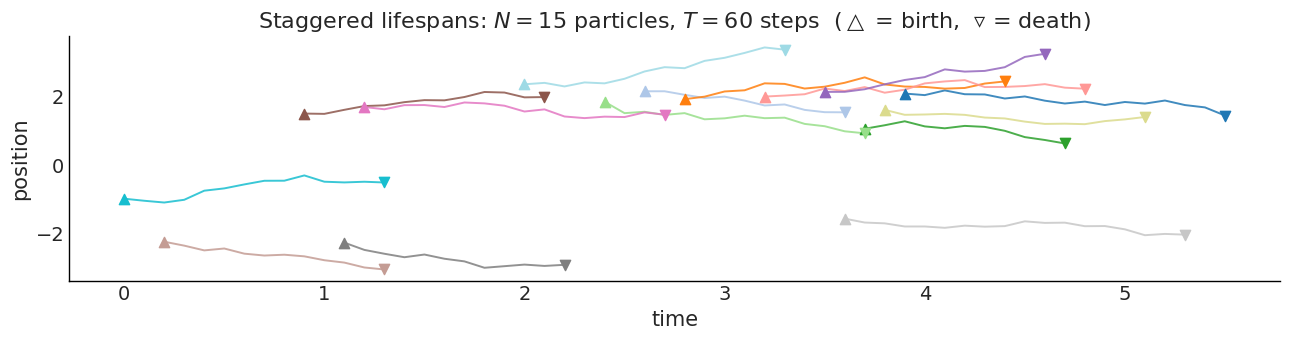

In [21]:
obs_np_st = np.asarray(obs_st)

fig, ax = plt.subplots(figsize=(13, 3.5))
for i in range(N_st):
    alive = ~np.isnan(obs_np_st[:, i])
    ax.plot(t_st_np[alive], obs_np_st[alive, i], color=colors_st[i], lw=1.4, alpha=0.85)
    ax.scatter(t_st_np[birth_steps[i]], obs_np_st[birth_steps[i], i],
               marker="^", s=55, color=colors_st[i], zorder=5)
    ax.scatter(t_st_np[death_steps[i]], obs_np_st[death_steps[i], i],
               marker="v", s=55, color=colors_st[i], zorder=5)
ax.set_xlabel("time")
ax.set_ylabel("position")
ax.set_title(fr"Staggered lifespans: $N={N_st}$ particles, $T={T_st}$ steps  "
             r"($\triangle$ = birth,  $\triangledown$ = death)")
plt.tight_layout()
plt.show()

SVI finished in 2.6s


coefficient:  true -1.0  |  posterior mean -1.323 ± 0.209
scale:        true 1.5   |  posterior mean 1.568 ± 0.170


/var/folders/2j/jdg5vjdx4x3_5tmlzl7nzygh0000gn/T/ipykernel_40794/1946580640.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


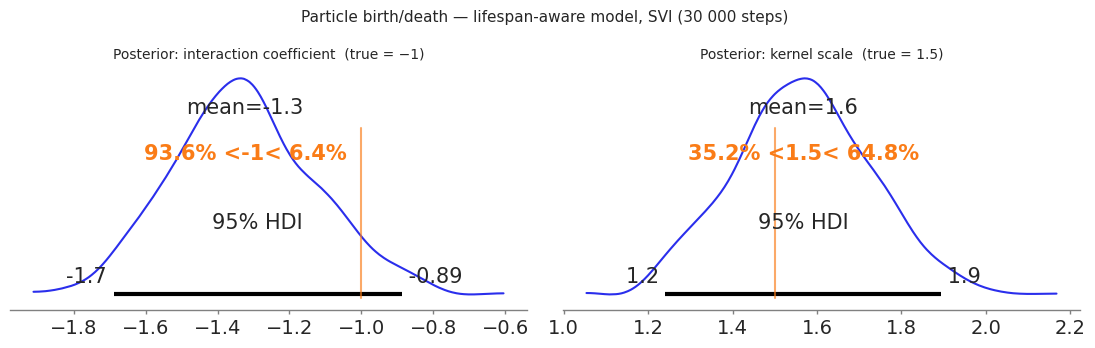

In [22]:
def conditioned_st():
    with DiscreteTimeSimulator():
        interacting_particles_lifespan_model(N=N_st, obs_times=t_st, obs_values=obs_st)


init_st  = {"coefficient": jnp.array(true_coeff_st), "scale": jnp.array(true_scale_st)}
guide_st = AutoNormal(conditioned_st, init_loc_fn=init_to_value(values=init_st))
svi_st   = SVI(conditioned_st, guide_st, optax.adam(2e-3), loss=Trace_ELBO())

t0 = time.time()
svi_res_st = svi_st.run(svi_key_st, num_steps=30000, progress_bar=False)
print(f"SVI finished in {time.time() - t0:.1f}s")

post_st       = guide_st.sample_posterior(jr.PRNGKey(20), svi_res_st.params, sample_shape=(500,))
post_coeff_st = np.asarray(post_st["coefficient"])
post_scale_st = np.asarray(post_st["scale"])
print(f"coefficient:  true {true_coeff_st:+.1f}  |  "
      f"posterior mean {post_coeff_st.mean():+.3f} ± {post_coeff_st.std():.3f}")
print(f"scale:        true {true_scale_st:.1f}   |  "
      f"posterior mean {post_scale_st.mean():.3f} ± {post_scale_st.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
az.plot_posterior(post_coeff_st, hdi_prob=0.95, ref_val=true_coeff_st, ax=axes[0])
axes[0].set_title("Posterior: interaction coefficient  (true = −1)", fontsize=10)
az.plot_posterior(post_scale_st, hdi_prob=0.95, ref_val=true_scale_st, ax=axes[1])
axes[1].set_title("Posterior: kernel scale  (true = 1.5)", fontsize=10)
fig.suptitle("Particle birth/death — lifespan-aware model, SVI (30 000 steps)", fontsize=11)
plt.tight_layout()
plt.show()

## Summary

| Section | Missingness pattern | Key mechanism |
|---|---|---|
| 3.1 | Whole-row, shorter output | `unroll_missing=False` (default) — rows filtered before simulation |
| 3.2 | Whole-row, full-length + imputation | `unroll_missing=True` — missing rows sampled from transition |
| 4 | Per-dimension partial | Two-mask scan via `masked_log_prob` (diagonal obs model required) |
| 6 | Per-particle contiguous gaps | Two-mask scan via correction factors, `DiracIdentityObservation` |
| 7 | Per-particle birth/death | Lifespan-aware `state_evolution` with `x_safe` and `alive` masking |

**Key takeaways:**

- Pass `NaN` directly in `obs_values` — no preprocessing required.
- Per-dimension partial missingness requires a **diagonal** observation model;
  correlated models (`LinearGaussianObservation`) raise `NotImplementedError`.
- Interacting-particle systems with per-particle gaps use `DiracIdentityObservation`
  and SVI (NUTS stalls on the flat-gradient correction-factor landscape).
- For birth/death: write a lifespan-aware `state_evolution` that zeros absent carries
  with `x_safe = jnp.where(alive, x, 0.0)` and masks absent particles from the
  interaction sum. Absent slots are treated as latent by the simulator automatically.